In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

from tdse_solutions import ion_ham, phase_residuals_rect

In [2]:
t_gate = 2*np.pi
t_arr = np.linspace(0, t_gate, 4001)

N_cutoff = 600
eta = 0.03

n_ions = 20
mx_arr = np.arange(-n_ions/2, n_ions/2+1)
f_max = 1/2
n_loops = 1
phase_arr_rect_1 = phase_residuals_rect(mx_arr, t_arr, f_max, n_loops, eta, N_cutoff)
phases_theory_rect_1 = np.exp(3j*np.pi/8*eta**2*mx_arr**4)
phonon_excitation = 1 - np.abs(phase_arr_rect_1)**2

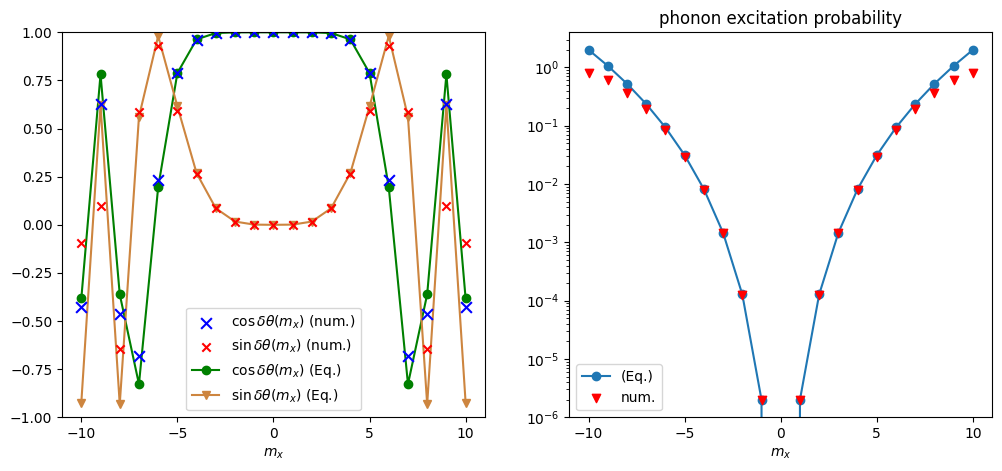

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
ax1.scatter(mx_arr, phase_arr_rect_1.real, color='blue', marker='x', zorder=3, s=60, label=r'$\cos{\delta\theta(m_x)}$ (num.)')
ax1.scatter(mx_arr, phase_arr_rect_1.imag, marker='x', color='red',  zorder=3, label=r'$\sin{\delta\theta(m_x)}$ (num.)')
ax1.plot(mx_arr, phases_theory_rect_1.real, color='green', marker='o', label=r'$\cos{\delta\theta(m_x)}$ (Eq.)')
ax1.plot(mx_arr, phases_theory_rect_1.imag, color='peru', marker='v', label=r'$\sin{\delta\theta(m_x)}$ (Eq.)')
#plt.gca().xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
ax1.set_xticks([-10, -5, 0, 5, 10])
ax1.set_xlabel('$m_x$')
#plt.ylabel('$\delta\theta(m_x)$')
ax1.set_ylim(-1, 1)
ax1.legend()

ax2.plot(mx_arr, np.pi**2/4*eta**4*mx_arr**6, marker='o', color='tab:blue', label='(Eq.)')
ax2.scatter(mx_arr, phonon_excitation, label='num.', color='red', marker='v', zorder=3)
ax2.set_xticks([-10, -5, 0, 5, 10])
ax2.set_xlabel('$m_x$')
ax2.set_title('phonon excitation probability')
ax2.set_yscale('log')
ax2.set_ylim(ymin=1e-6)

ax1.text

plt.savefig('../figures/rect_pulse_inf_contribs.pdf')
ax2.legend()

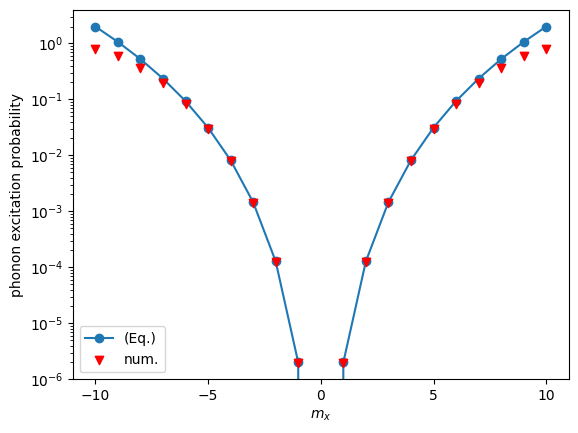

In [6]:
fig, ax2 = plt.subplots(1, 1)

ax2.plot(mx_arr, np.pi**2/4*eta**4*mx_arr**6, marker='o', color='tab:blue', label='(Eq.)')
ax2.scatter(mx_arr, phonon_excitation, label='num.', color='red', marker='v', zorder=3)
ax2.set_xticks([-10, -5, 0, 5, 10])
ax2.set_xlabel('$m_x$')
ax2.set_ylabel('phonon excitation probability')
ax2.set_yscale('log')
ax2.set_ylim(ymin=1e-6)
ax2.legend()
#plt.savefig('../figures/rect_pulse_phase_residuals.pdf')
plt.show()

In [13]:
help(ax1.annotate)

Help on method annotate in module matplotlib.axes._axes:

annotate(
    text,
    xy,
    xytext=None,
    xycoords='data',
    textcoords=None,
    arrowprops=None,
    annotation_clip=None,
    **kwargs
) method of matplotlib.axes._axes.Axes instance
    Annotate the point *xy* with text *text*.

    In the simplest form, the text is placed at *xy*.

    Optionally, the text can be displayed in another position *xytext*.
    An arrow pointing from the text to the annotated point *xy* can then
    be added by defining *arrowprops*.

    Parameters
    ----------
    text : str
        The text of the annotation.

    xy : (float, float)
        The point *(x, y)* to annotate. The coordinate system is determined
        by *xycoords*.

    xytext : (float, float), default: *xy*
        The position *(x, y)* to place the text at. The coordinate system
        is determined by *textcoords*.

    xycoords : single or two-tuple of str or `.Artist` or `.Transform` or callable, default: 'dat